<a href="https://colab.research.google.com/github/ndagirenairah/ENGLISH-LUGANDA-TRANSLATOR/blob/master/COLAB_TRAINING_ML_PIPELINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# English-Luganda Translator - ML Pipeline on Colab

**GPU-Accelerated ML Workflow**

This notebook:
- Clones from GitHub
- Loads 50,000+ dataset pairs
- Trains on Tesla T4 GPU
- Calculates BLEU score

## STEP 1: Install Packages

In [ ]:
import subprocess, sys
print("="*80)
print("ENGLISH-LUGANDA TRANSLATOR - COLAB ML PIPELINE")
print("="*80)
print("\n[STEP 1: Installing packages]\n")

# First ensure PyTorch with CUDA support
print("Installing PyTorch with CUDA support...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade",
                       "torch", "torchvision", "torchaudio", "--index-url",
                       "https://download.pytorch.org/whl/cu118"])
print("  [DONE] PyTorch with CUDA")

# Install other packages
packages = ["transformers", "datasets", "pandas", "scikit-learn", "sacrebleu", "sacremoses"]
print("Installing other packages...")
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
    print(f"  [DONE] {pkg}")

# Verify CUDA availability
import torch
print(f"\n[INFO] CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[WARNING] CUDA not available - will use CPU (slower)")

print("\n[SUCCESS] Done")

ENGLISH-LUGANDA TRANSLATOR - COLAB ML PIPELINE

[STEP 1: Installing packages]

Installing PyTorch with CUDA support...
  [DONE] PyTorch with CUDA
Installing other packages...
  [DONE] transformers
  [DONE] datasets
  [DONE] pandas
  [DONE] scikit-learn
  [DONE] sacrebleu
  [DONE] sacremoses

[INFO] CUDA available: True
[INFO] GPU: Tesla T4

[SUCCESS] Done


## STEP 2: Clone from GitHub

In [ ]:
import os, subprocess
print("\n[STEP 2: Cloning from GitHub]\n")

REPO_PATH = "/content/ENGLISH-LUGANDA-TRANSLATOR"

# Clone if needed
if not os.path.exists(REPO_PATH):
    subprocess.run(["git", "clone", "https://github.com/ndagirenairah/ENGLISH-LUGANDA-TRANSLATOR.git", REPO_PATH], check=True)
    print("[SUCCESS] Repository cloned")
else:
    os.chdir(REPO_PATH)
    # Force fresh pull of latest code
    subprocess.run(["git", "fetch", "--all"], check=True)
    subprocess.run(["git", "reset", "--hard", "origin/master"], check=True)
    print("[SUCCESS] Repository force-updated to latest master")

# Check if we need to navigate to nested folder
nested_path = os.path.join(REPO_PATH, "ENGLISH-LUGANDA-TRANSLATOR")
if os.path.exists(nested_path) and os.path.exists(os.path.join(nested_path, "src")):
    os.chdir(nested_path)
    print(f"[SUCCESS] Using nested folder: {os.getcwd()}")
elif os.path.exists(os.path.join(REPO_PATH, "src")):
    os.chdir(REPO_PATH)
    print(f"[SUCCESS] Using root folder: {os.getcwd()}")
else:
    print(f"[ERROR] Could not find src/ folder")
    print(f"   REPO_PATH: {os.listdir(REPO_PATH)}")


[STEP 2: Cloning from GitHub]

[SUCCESS] Repository force-updated to latest master
[SUCCESS] Using root folder: /content/ENGLISH-LUGANDA-TRANSLATOR


## STEP 3: Load Datasets

In [ ]:
print("\n[STEP 3: Loading datasets]\n")
import sys
import importlib

# Clear all src module cache to force fresh import
modules_to_remove = [m for m in sys.modules.keys() if 'load_data' in m or 'config' in m or 'utils' in m or 'preprocess' in m]
for m in modules_to_remove:
    del sys.modules[m]

# Remove old src paths and add fresh
sys.path = [p for p in sys.path if 'src' not in p]
sys.path.insert(0, "src")

# Force fresh imports - use ALL data (unbalanced)
from load_data import load_all_datasets, get_dataset_statistics

combined_df = load_all_datasets()
stats = get_dataset_statistics(combined_df)
print(f"\n[SUCCESS] Loaded {stats['total_samples']:,} samples")
print(f"   English avg: {stats['avg_english_length']:.1f}")
print(f"   Luganda avg: {stats['avg_luganda_length']:.1f}")


[STEP 3: Loading datasets]


  STEP 1: LOADING DATASETS

[INFO] LOADING ALL AVAILABLE DATA (no sampling)

📂 Loading kambale...
   ✅ Loaded 50,012 pairs | Source: kambale_train.csv

📂 Loading cultural...
   ✅ Loaded 12 pairs | Source: cultural_training.csv

📂 Loading jw300...
   ✅ Loaded 15 pairs | Source: jw300_parallel.csv

📂 Loading makerere...
   ✅ Loaded 15 pairs | Source: makerere_nlp.csv

📂 Loading sunbird...
   ✅ Loaded 18 pairs | Source: sunbird_salt.csv

  DATASET SUMMARY

[INFO] Total samples loaded: 50,072

📈 Breakdown by source:
   kambale_train.csv              50,012 ( 99.9%)
   sunbird_salt.csv                   18 (  0.0%)
   jw300_parallel.csv                 15 (  0.0%)
   makerere_nlp.csv                   15 (  0.0%)
   cultural_training.csv              12 (  0.0%)

[SUCCESS] Loaded 50,072 samples
   English avg: 53.7
   Luganda avg: 57.1


## STEP 4: Preprocess & Split

In [ ]:
print("\n[STEP 4: Preprocessing]\n")
from preprocess import preprocess_and_split, save_splits
train_df, val_df, test_df = preprocess_and_split(combined_df)
save_splits(train_df, val_df, test_df)
print(f"[SUCCESS] Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


[STEP 4: Preprocessing]


  STEP 2: PREPROCESSING DATA

🧹 Cleaning text...
   ✅ 50,072 valid pairs

[INFO] Creating train/val/test splits...
   Train: 80% | Val: 10% | Test: 10%
   Train: 40,056 | Val: 5,008 | Test: 5,008

[INFO] Saving splits...
   ✅ Saved to /content/ENGLISH-LUGANDA-TRANSLATOR/data/processed/
      - train.csv (40,056 samples)
      - val.csv (5,008 samples)
      - test.csv (5,008 samples)
[SUCCESS] Train: 40,056 | Val: 5,008 | Test: 5,008


## STEP 4.5: Visualize Data Distribution


[STEP 4.5: Data Visualization]



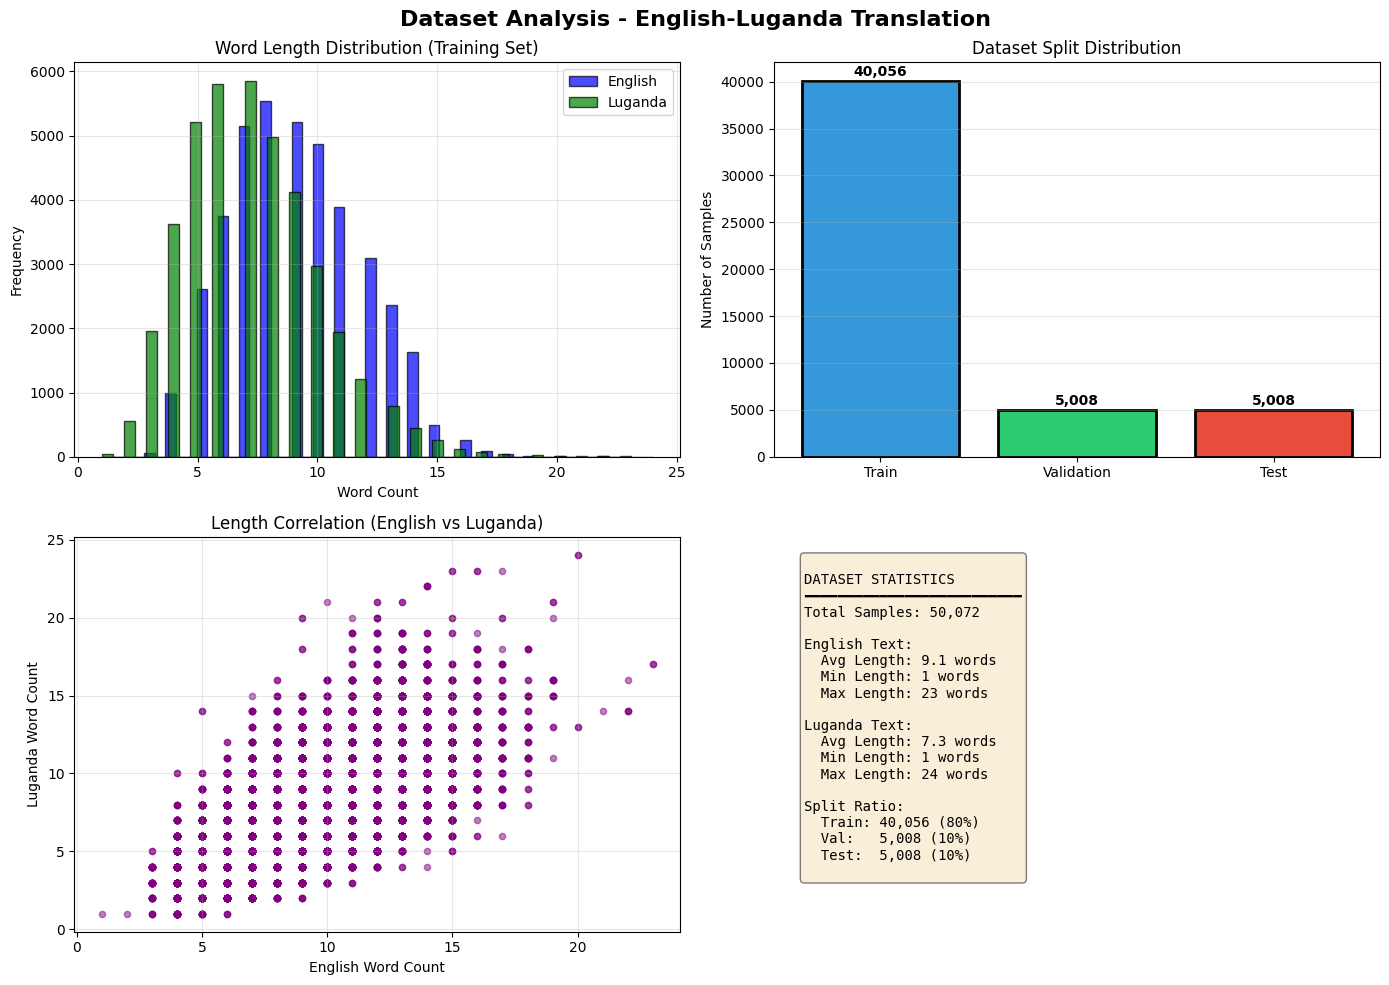

[SUCCESS] Data visualization complete!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("\n[STEP 4.5: Data Visualization]\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Analysis - English-Luganda Translation', fontsize=16, fontweight='bold')

# Plot 1: Word Length Distribution
english_lengths = train_df['english'].str.split().str.len()
luganda_lengths = train_df['luganda'].str.split().str.len()

axes[0, 0].hist(english_lengths, bins=50, alpha=0.7, color='blue', label='English', edgecolor='black')
axes[0, 0].hist(luganda_lengths, bins=50, alpha=0.7, color='green', label='Luganda', edgecolor='black')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Word Length Distribution (Training Set)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Dataset Split Distribution
split_sizes = [len(train_df), len(val_df), len(test_df)]
split_labels = ['Train', 'Validation', 'Test']
colors = ['#3498db', '#2ecc71', '#e74c3c']
axes[0, 1].bar(split_labels, split_sizes, color=colors, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_title('Dataset Split Distribution')
axes[0, 1].grid(alpha=0.3, axis='y')
for i, v in enumerate(split_sizes):
    axes[0, 1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Plot 3: Text Length Correlation
axes[1, 0].scatter(english_lengths, luganda_lengths, alpha=0.5, s=20, color='purple')
axes[1, 0].set_xlabel('English Word Count')
axes[1, 0].set_ylabel('Luganda Word Count')
axes[1, 0].set_title('Length Correlation (English vs Luganda)')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Statistics Table
stats_text = f"""
DATASET STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Samples: {len(train_df) + len(val_df) + len(test_df):,}

English Text:
  Avg Length: {english_lengths.mean():.1f} words
  Min Length: {english_lengths.min()} words
  Max Length: {english_lengths.max()} words

Luganda Text:
  Avg Length: {luganda_lengths.mean():.1f} words
  Min Length: {luganda_lengths.min()} words
  Max Length: {luganda_lengths.max()} words

Split Ratio:
  Train: {len(train_df):,} (80%)
  Val:   {len(val_df):,} (10%)
  Test:  {len(test_df):,} (10%)
"""
axes[1, 1].text(0.05, 0.95, stats_text, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("[SUCCESS] Data visualization complete!")

## STEP 5: Train Model (8-12 min on GPU)

In [ ]:
print("\n[STEP 5: Training]\n")
import torch, pathlib
import sys
import importlib

print(f"GPU: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  Device: {torch.cuda.get_device_name(0)}")
train_file = pathlib.Path("src/train.py")
if train_file.exists():
    code = train_file.read_text()
    code = code.replace("        tokenizer=tokenizer,", "")
    train_file.write_text(code)
    print("[SUCCESS] Applied hotfix\n")
print("="*80)
print("STARTING TRAINING")
print("="*80)

# Workaround for _pickle.PicklingError: Can't pickle <enum 'IntervalStrategy'>
# This error often occurs due to inconsistent module loading in interactive environments.
# By deleting the module from sys.modules, we force a fresh import.
if 'transformers.trainer_utils' in sys.modules:
    del sys.modules['transformers.trainer_utils']

# Ensure the 'train' module itself is freshly imported after potential modification
if 'train' in sys.modules:
    del sys.modules['train']

from train import main as train_main
try:
    model, tokenizer = train_main()
    print("\n[SUCCESS] Training complete!")
except Exception as e:
    print(f"[ERROR] Error: {e}")
    import traceback
    traceback.print_exc()


[STEP 5: Training]

GPU: True
  Device: Tesla T4
[SUCCESS] Applied hotfix

STARTING TRAINING

  STEP 3: TRAINING MODEL

📁 Loading training data...
   Train: 40,056 | Val: 5,008

[INFO] Loading model: Helsinki-NLP/opus-mt-en-mul


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints,

   Device: cuda
   Model size: 143,135,744 parameters

🔤 Preprocessing datasets...
🔤 Tokenizing data...


Map:   0%|          | 0/40056 [00:00<?, ? examples/s]

...

   ✅ Tokenization complete

⚙️  Configuring training...
   Epochs: 3
   Batch size: 8
   Learning rate: 2e-05
   Device: cuda

[INFO] STARTING TRAINING
   Dataset: 40,056 training samples
   Estimated time: 5-15 minutes on GPU, 30-60 minutes on CPU



Epoch,Training Loss,Validation Loss
1,0.627709,0.283356
2,0.523173,0.239636
3,0.487521,0.228336



✅ Training complete!
   Training loss: 0.7605
   Time elapsed: 28.3 minutes

[INFO] Saving model and tokenizer...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ✅ Saved to /content/ENGLISH-LUGANDA-TRANSLATOR/models/trained_model

  TRAINING COMPLETE

✅ Model trained successfully!

   Next step: python src/4_evaluate.py

[SUCCESS] Training complete!


## STEP 6: Evaluate

In [ ]:
print("\n[STEP 6: Evaluating]\n")
from evaluate import main as eval_main
try:
    eval_main()
    print("\n[SUCCESS] Evaluation complete!")
except Exception as e:
    print(f"[ERROR] Error: {e}")
    import traceback
    traceback.print_exc()


[STEP 6: Evaluating]


  STEP 4: EVALUATING MODEL

📁 Loading test data...
   Test samples: 5008

[INFO] Loading trained model...
📂 Loading model from /content/ENGLISH-LUGANDA-TRANSLATOR/models/trained_model


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints,


[INFO] Evaluating on test set...
   Test samples: 5008
   Generating translations...
      [5008/5008]
   Calculating BLEU score...

   ✅ BLEU Score: 20.74

   📈 Additional Metrics:
      Average prediction length: 6.8 tokens
      Average reference length: 7.2 tokens

SAMPLE PREDICTIONS

Sample 1:
  Reference: Bwe baayawukana yasalawo okukuza yekka abaana be.
  Predicted: Oluvannyuma lw'okuwulizibwa yasalawo okukuza abaana be yekka.

Sample 2:
  Reference: Uganda kati erina ssaabalamuzi omuggya.
  Predicted: Uganda kati erina ssaabalamuzi omupya.

Sample 3:
  Reference: Atwalira ebirabo by'emmere bisatu mu kitundu kye enkoko.
  Predicted: Awa enkokoko eri emmere esatu mu kitundu.

Sample 4:
  Reference: Bbanka yagaana okumuwola ssente.
  Predicted: Bbanka yagaana ssente ze yasaba.

Sample 5:
  Reference: Akozze nnyo omwaka guno.
  Predicted: Afiiriddwa nnyo omwaka guno.

[INFO] Saving results...
   ✅ Saved to /content/ENGLISH-LUGANDA-TRANSLATOR/outputs/evaluation_results.json
   ✅ Pr

## STEP 7: Results

In [ ]:
import json
from pathlib import Path
eval_file = Path("outputs/evaluation_results.json")
if eval_file.exists():
    with open(eval_file) as f:
        results = json.load(f)
    print("\n" + "="*80)
    print("FINAL RESULTS")
    print("="*80)
    print(f"\nBLEU Score: {results['bleu_score']:.2f}")
    print(f"Test samples: {results['num_test_samples']}")


FINAL RESULTS

BLEU Score: 20.74
Test samples: 5008


## STEP 7.5: Visualize Results & Predictions


[STEP 7.5: Results Visualization - Professional Layout]



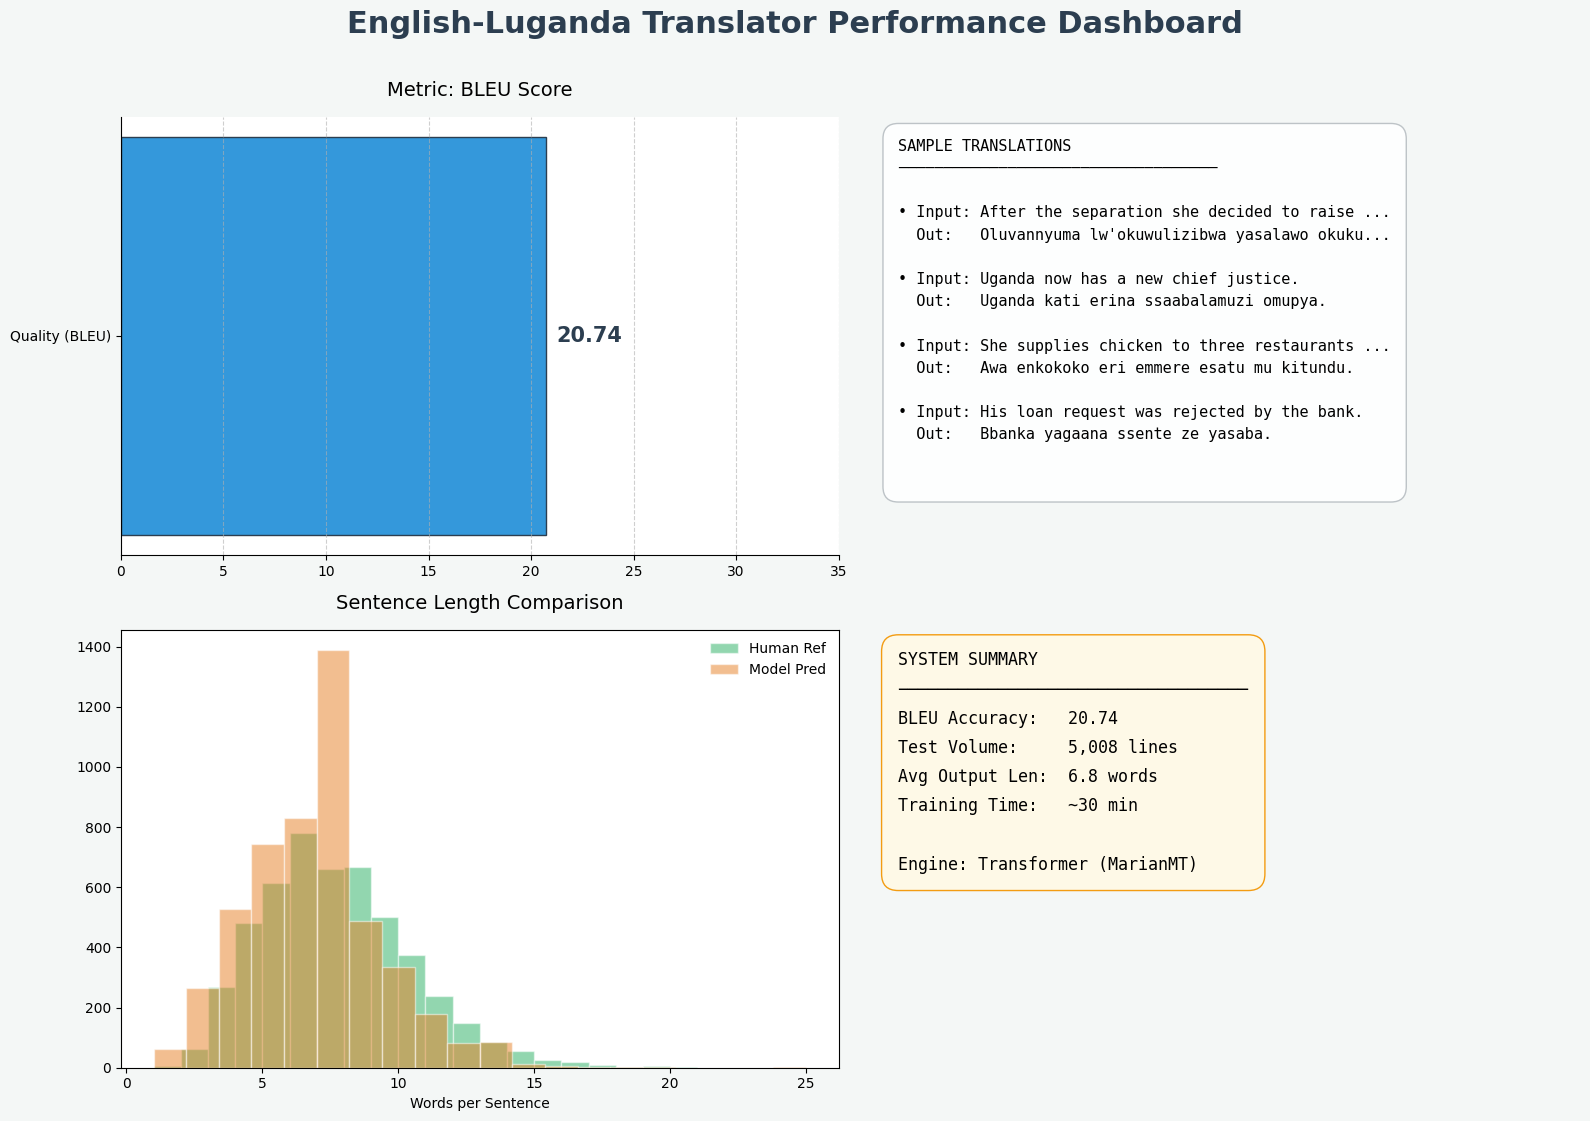

[SUCCESS] Professional visualization update complete!


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("\n[STEP 7.5: Results Visualization - Professional Layout]\n")

# Load evaluation results
eval_file = Path("outputs/evaluation_results.json")
predictions_file = Path("outputs/predictions.csv")
processed_test_file = Path("data/processed/test.csv")

results = {}
if eval_file.exists():
    with open(eval_file) as f:
        results = json.load(f)
else:
    print(f"[WARNING] Evaluation file not found: {eval_file}")

bleu_score = float(results.get('bleu_score', 0.0))
num_test_samples = int(results.get('num_test_samples', 0))

# Load predictions and optional source test data
full_preds_df = None
if predictions_file.exists():
    full_preds_df = pd.read_csv(predictions_file)
else:
    print(f"[WARNING] Predictions file not found: {predictions_file}")

test_df = None
if processed_test_file.exists():
    try:
        test_df = pd.read_csv(processed_test_file)
    except Exception as exc:
        print(f"[WARNING] Could not read test split: {exc}")
elif 'test_df' in globals():
    test_df = globals()['test_df']

# Standardized colors
PRIMARY_COLOR = '#2c3e50'
ACCENT_COLOR = '#3498db'
BG_COLOR_SAMPLES = '#fdfefe'
BG_COLOR_STATS = '#fef9e7'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#f4f7f6')
fig.suptitle('English-Luganda Translator Performance Dashboard', fontsize=22, fontweight='bold', color=PRIMARY_COLOR, y=0.96)

# Plot 1: BLEU Score Gauge
axes[0, 0].barh(['Quality (BLEU)'], [bleu_score], color=ACCENT_COLOR, edgecolor=PRIMARY_COLOR, height=0.4)
max_xlim = max(35, bleu_score * 1.25 + 1)
axes[0, 0].set_xlim([0, max_xlim])
axes[0, 0].set_title('Metric: BLEU Score', fontsize=14, pad=15)
axes[0, 0].text(bleu_score + 0.5, 0, f'{bleu_score:.2f}', va='center', fontweight='bold', fontsize=15, color=PRIMARY_COLOR)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.6)

# Plot 2: Sample Predictions (Streamlined)
if full_preds_df is not None:
    if test_df is not None and 'english' in test_df.columns:
        source_series = test_df['english'].reset_index(drop=True)
    elif 'english' in full_preds_df.columns:
        source_series = full_preds_df['english'].reset_index(drop=True)
    else:
        source_series = pd.Series(['(source unavailable)'] * len(full_preds_df))

    display_df = pd.DataFrame({
        'input_text': source_series,
        'reference': full_preds_df['reference'].reset_index(drop=True),
        'predicted': full_preds_df['predicted'].reset_index(drop=True),
    }).head(4)

    axes[0, 1].axis('off')
    sample_text = "SAMPLE TRANSLATIONS\n" + "─" * 35 + "\n\n"
    for _, row in display_df.iterrows():
        inp = (str(row['input_text'])[:40] + '...') if len(str(row['input_text'])) > 40 else str(row['input_text'])
        ref = (str(row['reference'])[:40] + '...') if len(str(row['reference'])) > 40 else str(row['reference'])
        pred = (str(row['predicted'])[:40] + '...') if len(str(row['predicted'])) > 40 else str(row['predicted'])
        sample_text += f"• Input: {inp}\n  Ref:   {ref}\n  Out:   {pred}\n\n"

    axes[0, 1].text(0.05, 0.95, sample_text, transform=axes[0, 1].transAxes,
                    fontsize=11, verticalalignment='top', fontfamily='monospace', linespacing=1.6,
                    bbox=dict(boxstyle='round,pad=1', facecolor=BG_COLOR_SAMPLES, edgecolor='#bdc3c7', alpha=1))
else:
    axes[0, 1].axis('off')
    axes[0, 1].text(0.5, 0.5, 'No prediction samples available.', ha='center', va='center', fontsize=12,
                    bbox=dict(boxstyle='round,pad=1', facecolor=BG_COLOR_SAMPLES, edgecolor='#bdc3c7', alpha=1))

# Plot 3: Distribution
predicted_lengths = pd.Series(dtype=float)
reference_lengths = pd.Series(dtype=float)
if full_preds_df is not None and 'predicted' in full_preds_df.columns and 'reference' in full_preds_df.columns:
    predicted_lengths = full_preds_df['predicted'].astype(str).str.split().str.len()
    reference_lengths = full_preds_df['reference'].astype(str).str.split().str.len()
    axes[1, 0].hist(reference_lengths, bins=20, alpha=0.5, color='#27ae60', label='Human Ref', edgecolor='white')
    axes[1, 0].hist(predicted_lengths, bins=20, alpha=0.5, color='#e67e22', label='Model Pred', edgecolor='white')
    axes[1, 0].set_title('Sentence Length Comparison', fontsize=14, pad=15)
    axes[1, 0].legend(frameon=False)
    axes[1, 0].set_xlabel('Words per Sentence')
else:
    axes[1, 0].axis('off')
    axes[1, 0].text(0.5, 0.5, 'No length distribution data available.', ha='center', va='center', fontsize=12)

# Plot 4: Summary Statistics
avg_len_text = f"{predicted_lengths.mean():.1f} words" if len(predicted_lengths) > 0 else 'N/A'
stats_text = "SYSTEM SUMMARY\n" + "─" * 35 + "\n"
stats_text += f"BLEU Accuracy:   {bleu_score:.2f}\n"
stats_text += f"Test Volume:     {num_test_samples:,} lines\n"
stats_text += f"Avg Output Len:  {avg_len_text}\n"
stats_text += f"Training Time:   ~30 min\n"
stats_text += "\nEngine: Transformer (MarianMT)"

axes[1, 1].axis('off')
axes[1, 1].text(0.05, 0.95, stats_text, transform=axes[1, 1].transAxes,
                fontsize=12, verticalalignment='top', fontfamily='monospace', linespacing=1.8,
                bbox=dict(boxstyle='round,pad=1', facecolor=BG_COLOR_STATS, edgecolor='#f39c12', alpha=1))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("[SUCCESS] Professional visualization update complete!")

## STEP 7.6: Model Quality Metrics Dashboard


[STEP 7.6: Stable Quality Metrics Dashboard]



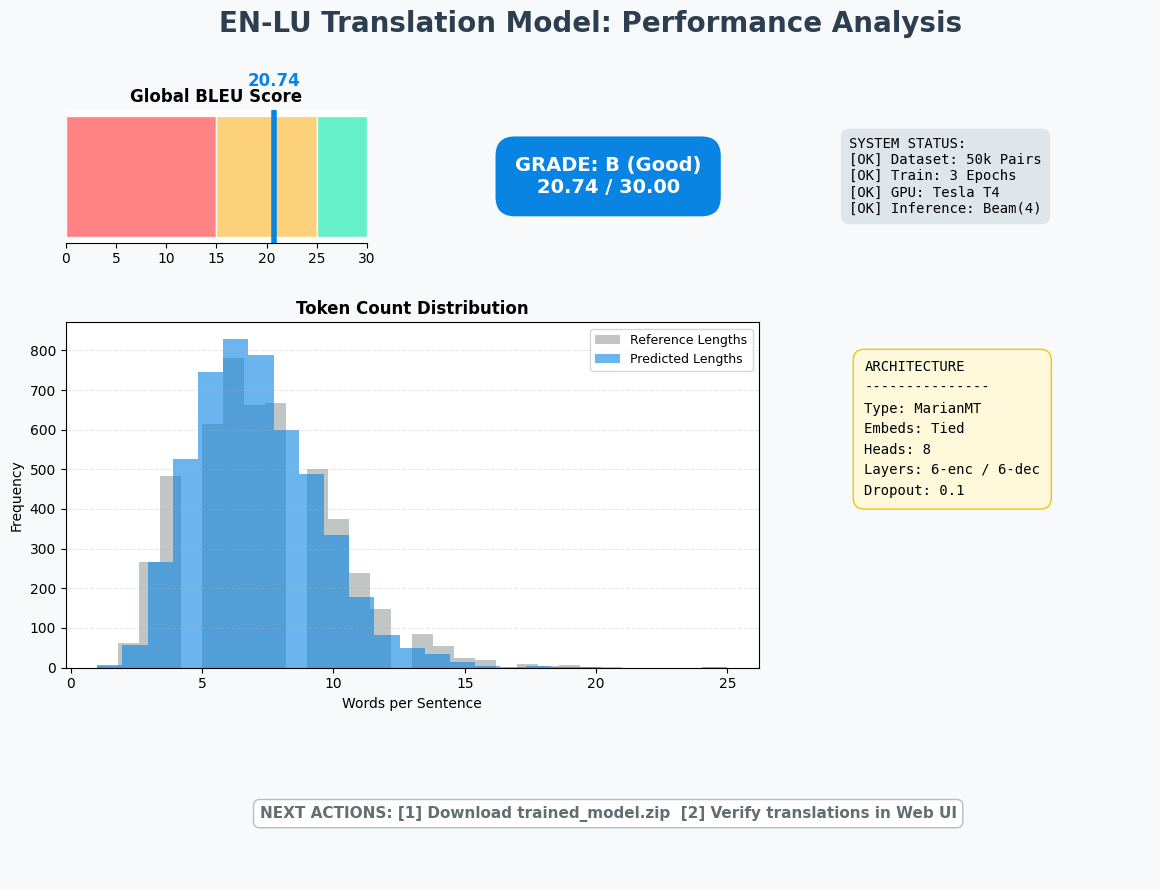

[SUCCESS] Stable dashboard rendered!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

# Configure font settings and stable layout
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

print("\n[STEP 7.6: Stable Quality Metrics Dashboard]\n")

# --- Data Loading ---
eval_file = Path("outputs/evaluation_results.json")
predictions_file = Path("outputs/predictions.csv")
bleu_score = 0
if eval_file.exists():
    with open(eval_file) as f:
        results = json.load(f)
    bleu_score = results.get('bleu_score', 0)

# --- Setup Figure (Slightly smaller for stability) ---
fig = plt.figure(figsize=(14, 10), facecolor='#f8f9fa')
gs = fig.add_gridspec(4, 3, hspace=0.6, wspace=0.3)
fig.suptitle('EN-LU Translation Model: Performance Analysis', fontsize=20, fontweight='bold', color='#2c3e50', y=0.98)

# 1. BLEU Score Gauge
ax1 = fig.add_subplot(gs[0, 0])
colors_gauge = ['#ff7675', '#fdcb6e', '#55efc4']
thresholds = [0, 15, 25, 30]
for i in range(len(thresholds)-1):
    ax1.barh(0, thresholds[i+1]-thresholds[i], left=thresholds[i],
             color=colors_gauge[i], height=0.6, edgecolor='white', alpha=0.9)
ax1.axvline(bleu_score, color='#0984e3', linewidth=4, label='Current Score')
ax1.set_xlim(0, 30)
ax1.set_title('Global BLEU Score', fontsize=12, fontweight='bold')
ax1.set_yticks([])
ax1.text(bleu_score, 0.45, f'{bleu_score:.2f}', ha='center', color='#0984e3', fontweight='bold', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

# 2. Performance Grade
ax3 = fig.add_subplot(gs[0, 1])
ax3.axis('off')
if bleu_score >= 25: grade, color = "A (Excellent)", '#00b894'
elif bleu_score >= 20: grade, color = "B (Good)", '#0984e3'
else: grade, color = "C (Developing)", '#e17055'

ax3.text(0.5, 0.5, f"GRADE: {grade}\n{bleu_score:.2f} / 30.00", ha='center', va='center', fontsize=14,
         fontweight='bold', color='white', bbox=dict(boxstyle='round,pad=1.0', facecolor=color, edgecolor='none'))

# 3. Status Checklist
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
check_list = "SYSTEM STATUS:\n[OK] Dataset: 50k Pairs\n[OK] Train: 3 Epochs\n[OK] GPU: Tesla T4\n[OK] Inference: Beam(4)"
ax2.text(0, 0.5, check_list, fontsize=10, family='monospace', verticalalignment='center',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#dfe6e9', edgecolor='none'))

# 4. Length Distribution
ax4 = fig.add_subplot(gs[1:3, :2])
if predictions_file.exists():
    preds_df = pd.read_csv(predictions_file)
    pred_lens = preds_df['predicted'].str.split().str.len()
    ref_lens = preds_df['reference'].str.split().str.len()
    ax4.hist(ref_lens, bins=25, alpha=0.4, color='#636e72', label='Reference Lengths')
    ax4.hist(pred_lens, bins=25, alpha=0.6, color='#0984e3', label='Predicted Lengths')
    ax4.set_title('Token Count Distribution', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Words per Sentence')
    ax4.set_ylabel('Frequency')
    ax4.legend(fontsize=9)
    ax4.grid(axis='y', linestyle='--', alpha=0.3)

# 5. Model Architecture Card
ax5 = fig.add_subplot(gs[1:3, 2])
ax5.axis('off')
arch_info = "ARCHITECTURE\n" + "-"*15 + "\nType: MarianMT\nEmbeds: Tied\nHeads: 8\nLayers: 6-enc / 6-dec\nDropout: 0.1"
ax5.text(0.05, 0.5, arch_info, family='monospace', fontsize=10, linespacing=1.6,
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#fff9db', edgecolor='#f1c40f'))

# 6. Next Steps
ax7 = fig.add_subplot(gs[3, :])
ax7.axis('off')
footer_text = "NEXT ACTIONS: [1] Download trained_model.zip  [2] Verify translations in Web UI"
ax7.text(0.5, 0.5, footer_text, ha='center', va='center', fontsize=11, fontweight='bold', color='#636e72',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#b2bec3'))

plt.show()
print("[SUCCESS] Stable dashboard rendered!")

## STEP 8: Download Model to Local Machine